<a href="https://colab.research.google.com/github/red-gunslinger/Int-Comp/blob/main/Redes_Convolucionales_con_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Convolutional Neural Networks with CIFAR-10

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

load the CIFAR-10 dataset using torchvision and convert the PIL images to tensors.

In [3]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [00:05<00:00, 33.1MB/s]


In [4]:
batch_size = 32

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=True)

Model 1 has 3 convolution layers with 25, 50, and 75 filters, each followed by ReLU and max pooling. The classifier has a single fully connected layer with dropout.

In [5]:
IMG_CHANNELS = 3

model_1 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 16 x 16

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 8 x 8

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 4 x 4

    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 10)
).to(device)

define the optimizer, epochs, and loss function.

In [6]:
optimizer_1 = Adam(model_1.parameters())
epochs = 20
loss_function = nn.CrossEntropyLoss()

define the accuracy helper and training function.

In [7]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

def train(_model, _train_loader, _test_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _test_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_test_loader.dataset))

        epoch_test_loss = val_loss / len(_test_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            test_loss=f"{epoch_test_loss:.4f}",
            test_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['test_loss'].append(epoch_test_loss)
        res['test_acc'].append(val_acc)

    return res

In [8]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x, y = x.to(device), y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))
    return (test_loss / len(_test_loader.dataset)), test_acc

In [9]:
def plot_learning_curves(res, _num_epochs):
    r = range(1, _num_epochs + 1)
    plt.plot(r, res['train_loss'], label="Train Loss")
    plt.plot(r, res['test_loss'], label="Test Loss")
    plt.plot(r, res['train_acc'], label="Train Accuracy")
    plt.plot(r, res['test_acc'], label="Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.title("Learning Curves")
    plt.legend()
    plt.show()

train the first model.

In [10]:
cnn_res_1 = train(model_1, train_loader, test_loader, loss_function, optimizer_1, epochs)

Training: 100%|██████████| 20/20 [04:33<00:00, 13.68s/epoch, test_acc=0.7463, test_loss=0.8832, train_acc=0.8856, train_loss=0.3202]


In [11]:
test_loss_1, test_acc_1 = test(model_1, test_loader, loss_function)
print(f"Model 1 accuracy: {test_acc_1:.4f}")

Model 1 accuracy: 0.7463


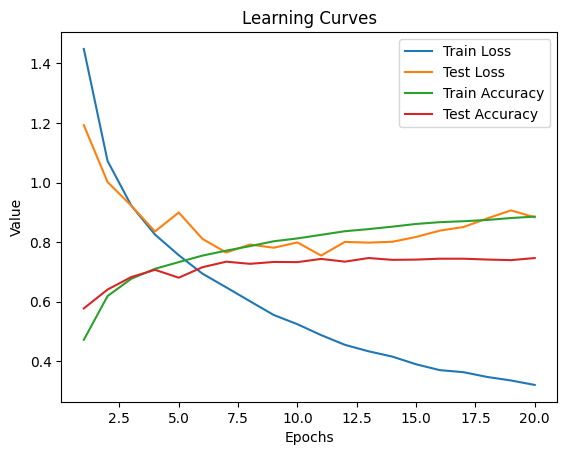

In [12]:
plot_learning_curves(cnn_res_1, epochs)

Model 2 uses smaller filters and an extra fully connected layer with less dropout.

In [13]:
model_2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 15, 3, stride=1, padding=1),  # 15 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 15 x 16 x 16

    nn.Conv2d(15, 30, 3, stride=1, padding=1),  # 30 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 30 x 8 x 8

    nn.Conv2d(30, 45, 3, stride=1, padding=1),  # 45 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 45 x 4 x 4

    nn.Flatten(),
    nn.Linear(45 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

optimizer_2 = Adam(model_2.parameters())
cnn_res_2 = train(model_2, train_loader, test_loader, loss_function, optimizer_2, epochs)

Training: 100%|██████████| 20/20 [04:28<00:00, 13.41s/epoch, test_acc=0.7244, test_loss=0.8733, train_acc=0.8530, train_loss=0.4067]


In [14]:
test_loss_2, test_acc_2 = test(model_2, test_loader, loss_function)
print(f"Model 2 accuracy: {test_acc_2:.4f}")

Model 2 accuracy: 0.7244


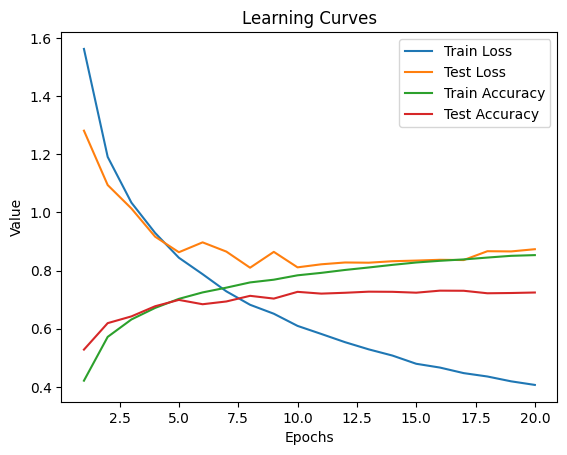

In [15]:
plot_learning_curves(cnn_res_2, epochs)

Model 3 uses larger filters and a deeper classifier with graduated dropout.

In [16]:
model_3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),  # 32 x 32 x 32
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 32 x 16 x 16

    nn.Conv2d(32, 64, 3, stride=1, padding=1),  # 64 x 16 x 16
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 64 x 8 x 8

    nn.Conv2d(64, 128, 3, stride=1, padding=1),  # 128 x 8 x 8
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 128 x 4 x 4

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.ReLU(),
    nn.Dropout(.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(.2),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(device)

optimizer_3 = Adam(model_3.parameters())
cnn_res_3 = train(model_3, train_loader, test_loader, loss_function, optimizer_3, epochs)

Training: 100%|██████████| 20/20 [04:56<00:00, 14.81s/epoch, test_acc=0.7358, test_loss=0.8578, train_acc=0.8688, train_loss=0.3784]


In [17]:
test_loss_3, test_acc_3 = test(model_3, test_loader, loss_function)
print(f"Model 3 accuracy: {test_acc_3:.4f}")

Model 3 accuracy: 0.7358


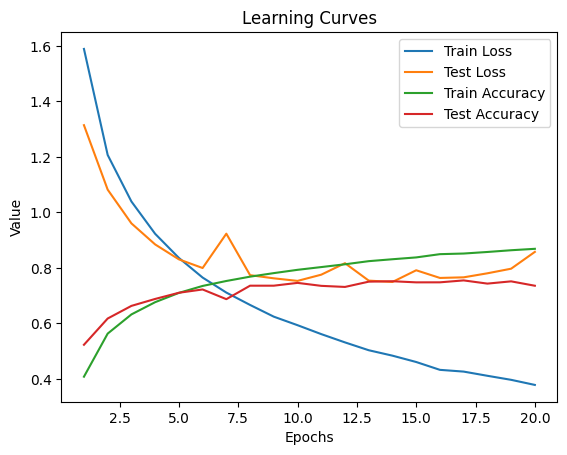

In [18]:
plot_learning_curves(cnn_res_3, epochs)

In [19]:
print(f"Model 1 accuracy: {test_acc_1:.4f}")
print(f"Model 2 accuracy: {test_acc_2:.4f}")
print(f"Model 3 accuracy: {test_acc_3:.4f}")

Model 1 accuracy: 0.7463
Model 2 accuracy: 0.7244
Model 3 accuracy: 0.7358


The three models all use 3 convolutional layers but differ in filter sizes and fully connected layers.
Model 1 with medium sized filters performed well as a baseline.
Model 2 with smaller filters had less capacity to learn features, resulting in lower accuracy.
Model 3 with larger filters had the most capacity but didn't always outperform model 1 due to potential overfitting.

As I see it, CNNs are effective for image classification on CIFAR 10. There could also be more imporvments for the results with some tuning on the architecture and hyperparameters.